# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")
os.makedirs("models", exist_ok=True)

# Step 1: Load dataset

In [44]:
df = pd.read_csv("/content/fertilizer_recommendation_dataset.csv")

In [45]:
print("Data shape:", df.shape)

Data shape: (3100, 12)


In [46]:
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [47]:
# Drop remarks from df used for training 
df = df.drop(columns=[c for c in df.columns if "remark" in c.lower()])
print("After dropping remarks, shape:", df.shape)

After dropping remarks, shape: (3100, 11)


In [49]:
TARGET_COL = "Fertilizer"   




In [50]:
# Identify columns that look like fertilizer-related 
suspected_leak_cols = [c for c in df.columns if "fert" in c.lower() or "Fertilizer" in c and c != TARGET_COL]
print("Suspected leakage columns (will NOT automatically drop target):", suspected_leak_cols)

# Show duplicate rows count
print("Duplicate rows in dataset:", df.duplicated().sum())


Suspected leakage columns (will NOT automatically drop target): ['Fertilizer']
Duplicate rows in dataset: 0


In [51]:
assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found. Edit TARGET_COL if needed."


# We will drop any other columns that explicitly equal the target name (rare)
drop_cols = [TARGET_COL]
features = [c for c in df.columns if c not in drop_cols]

print("Feature columns used for training:", features)

Feature columns used for training: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil', 'Crop']


In [52]:
# Fill numeric with median, categorical with mode
num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in features if c not in num_cols]

print("Numeric features:", num_cols)
print("Categorical features:", cat_cols)

# Fill missing values
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode().iloc[0] if not df[c].mode().empty else "NA")

# Show counts after fill
print("\nMissing values after fill:")
print(df[features].isna().sum())

Numeric features: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']
Categorical features: ['Soil', 'Crop']

Missing values after fill:
Temperature    0
Moisture       0
Rainfall       0
PH             0
Nitrogen       0
Phosphorous    0
Potassium      0
Carbon         0
Soil           0
Crop           0
dtype: int64


In [53]:
label_encoders = {}
df_encoded = df[features].copy()

for c in cat_cols:
    le = LabelEncoder()
    df_encoded[c] = le.fit_transform(df_encoded[c].astype(str))
    label_encoders[c] = le

display(df_encoded.head(4))

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,2,28
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,2,28
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,4,28
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,2,28


In [54]:
# Encode target
target_le = LabelEncoder()
y = target_le.fit_transform(df[TARGET_COL].astype(str))

# Fit scaler on numeric columns only and store num_cols
scaler = StandardScaler()
if num_cols:
    df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

X = df_encoded.values  # final feature matrix (numeric-scaled + encoded categorical)
print("Final X shape:", X.shape, "y shape:", y.shape)
print("Target classes:", target_le.classes_)
print("Class distribution:", Counter(y))

Final X shape: (3100, 10) y shape: (3100,)
Target classes: ['Balanced NPK Fertilizer' 'Compost' 'DAP' 'General Purpose Fertilizer'
 'Gypsum' 'Lime' 'Muriate of Potash' 'Organic Fertilizer' 'Urea'
 'Water Retaining Fertilizer']
Class distribution: Counter({np.int64(2): 1054, np.int64(9): 675, np.int64(1): 375, np.int64(6): 326, np.int64(5): 181, np.int64(0): 157, np.int64(8): 154, np.int64(7): 95, np.int64(4): 52, np.int64(3): 31})


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (2480, 10) Test shape: (620, 10)


In [64]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = {
    "lr__C": [0.01, 0.1, 1, 10, 100],
    "lr__penalty": ["l2"],
    "lr__solver": ["lbfgs"],
    "lr__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    lr_pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_lr = grid.best_estimator_

print("Best Logistic Regression params:", grid.best_params_)

Best Logistic Regression params: {'lr__C': 100, 'lr__class_weight': None, 'lr__penalty': 'l2', 'lr__solver': 'lbfgs'}


In [65]:
models = {
    "LogisticRegression": best_lr,
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),

}

results = {}
fitted_models = {}

for name, m in models.items():
    print(f"\nTraining {name} ...")
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    fitted_models[name] = m
    print(f"{name} test accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_le.classes_, zero_division=0))


Training LogisticRegression ...
LogisticRegression test accuracy: 0.8500
                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.78      0.68      0.72        31
                   Compost       0.83      0.87      0.85        75
                       DAP       0.93      0.94      0.93       211
General Purpose Fertilizer       0.50      0.67      0.57         6
                    Gypsum       0.86      0.55      0.67        11
                      Lime       0.67      0.39      0.49        36
         Muriate of Potash       0.76      0.82      0.79        65
        Organic Fertilizer       0.64      0.84      0.73        19
                      Urea       0.91      0.94      0.92        31
Water Retaining Fertilizer       0.87      0.90      0.88       135

                  accuracy                           0.85       620
                 macro avg       0.77      0.76      0.76       620
              weighted avg       0.85   

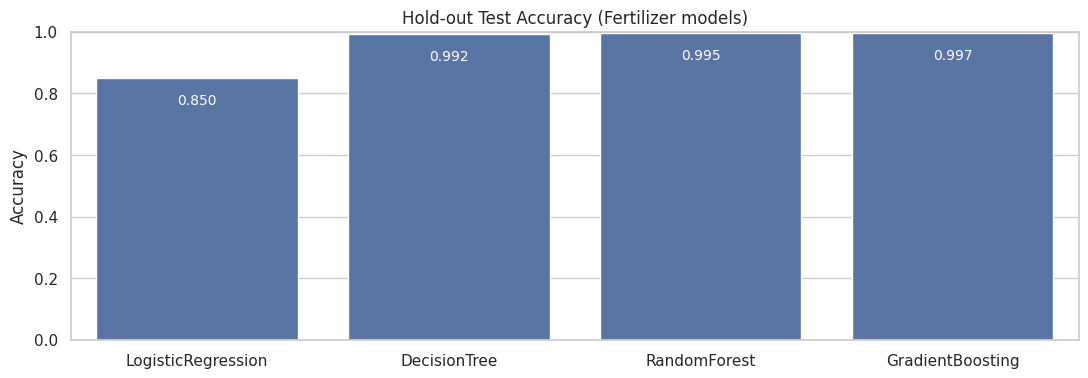

In [67]:
#Comparisons
plt.figure(figsize=(13,4))
names = list(results.keys())
vals = [results[n] for n in names]
sns.barplot(x=names, y=vals)
plt.ylim(0,1)
plt.title("Hold-out Test Accuracy (Fertilizer models)")
plt.ylabel("Accuracy")
for i,v in enumerate(vals):
    plt.text(i, v - 0.05, f"{v:.3f}", ha='center', va='top', color='white', fontsize=10)
plt.show()



Best model selected: GradientBoosting (accuracy=0.9968)


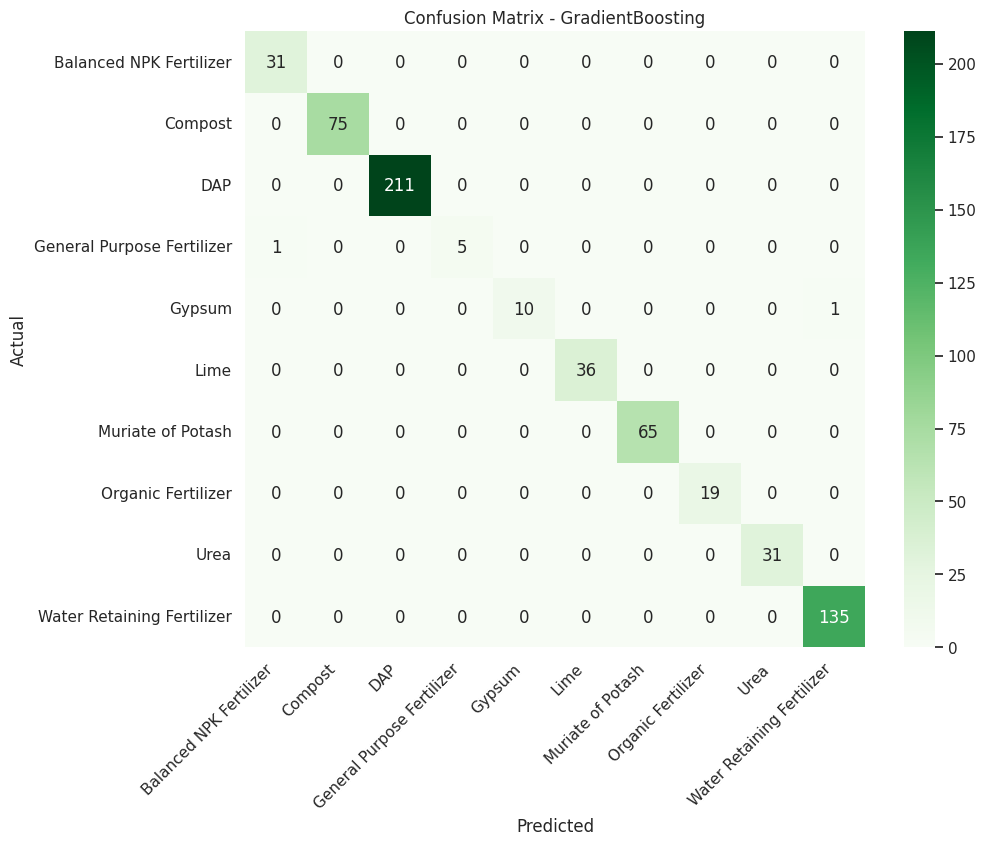


Classification report (best model):

                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.97      1.00      0.98        31
                   Compost       1.00      1.00      1.00        75
                       DAP       1.00      1.00      1.00       211
General Purpose Fertilizer       1.00      0.83      0.91         6
                    Gypsum       1.00      0.91      0.95        11
                      Lime       1.00      1.00      1.00        36
         Muriate of Potash       1.00      1.00      1.00        65
        Organic Fertilizer       1.00      1.00      1.00        19
                      Urea       1.00      1.00      1.00        31
Water Retaining Fertilizer       0.99      1.00      1.00       135

                  accuracy                           1.00       620
                 macro avg       1.00      0.97      0.98       620
              weighted avg       1.00      1.00      1.00       620



In [68]:
best_name = max(results, key=results.get)
best_model = fitted_models[best_name]
print(f"Best model selected: {best_name} (accuracy={results[best_name]:.4f})")

# Predictions and confusion matrix
y_best_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_best_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# Print classification report one more time
print("\nClassification report (best model):\n")
print(classification_report(y_test, y_best_pred, target_names=target_le.classes_, zero_division=0))

Top feature importances:


,0
Phosphorous,0.522004
Carbon,0.122264
Potassium,0.115435
Nitrogen,0.107187
Moisture,0.075259
PH,0.046807
Soil,0.010405
Crop,0.000294
Temperature,0.000185
Rainfall,0.000160


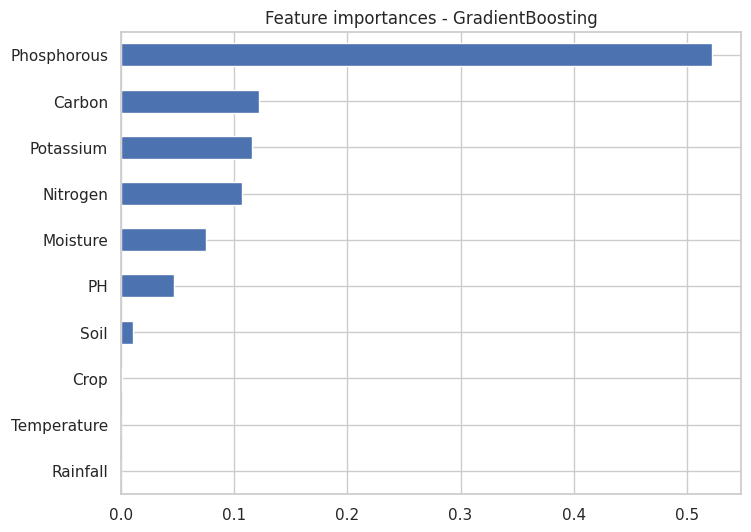

In [69]:
# Feature importance (if model supports it) ---
if hasattr(best_model, "feature_importances_"):
    feat_imp = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=False)
    print("Top feature importances:")
    display(feat_imp.head(20))

    plt.figure(figsize=(8,6))
    feat_imp.head(20).plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"Feature importances - {best_name}")
    plt.show()
else:
    print("Best model does not expose feature_importances_.")

In [70]:
# Save Model
save_dict = {
    "fert_model": best_model,
    "fert_encoder": target_le,
    "scaler": scaler,
    "feature_encoders": label_encoders,
    "features": features,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
}

# Save as a single pickle for convenience
with open("models/fertilizer_model_bundle.pkl", "wb") as f:
    pickle.dump(save_dict, f)

print("Saved model bundle to 'models/fertilizer_model_bundle.pkl'")

Saved model bundle to 'models/fertilizer_model_bundle.pkl'


In [71]:
# Create a demo sample using median/mode defaults
sample = {}
for c in features:
    if c in num_cols:
        sample[c] = float(df[c].median()) if c in df.columns else 0.0
    else:
        sample[c] = df[c].mode().iloc[0] if c in df.columns else (list(label_encoders[c].classes_)[0] if c in label_encoders else 0)

print("Sample input (raw):")
print(sample)

# Encode & scale sample
sample_enc = []
for c in features:
    val = sample[c]
    if c in label_encoders:
        val = label_encoders[c].transform([val])[0]
    sample_enc.append(val)
sample_arr = np.array(sample_enc).reshape(1, -1)

# scale numeric part
if num_cols:
    # find numeric indices
    num_indices = [features.index(c) for c in num_cols]
    cat_indices = [i for i in range(len(features)) if i not in num_indices]
    sample_num = sample_arr[:, num_indices]
    sample_cat = sample_arr[:, cat_indices] if cat_indices else np.empty((1,0))
    sample_num_scaled = scaler.transform(sample_num)
    sample_final = np.concatenate([sample_num_scaled, sample_cat], axis=1)
else:
    sample_final = sample_arr

pred_enc = best_model.predict(sample_final)[0]
pred_name = target_le.inverse_transform([pred_enc])[0]
print("\nDemo predicted fertilizer:", pred_name)

Sample input (raw):
{'Temperature': 26.13293769, 'Moisture': 0.5995202065, 'Rainfall': 96.48593534, 'PH': 6.337308221, 'Nitrogen': 59.429648795, 'Phosphorous': 58.205269165000004, 'Potassium': 58.710808465, 'Carbon': 1.4633573595, 'Soil': 'Acidic Soil', 'Crop': 'Adzuki Beans'}

Demo predicted fertilizer: Water Retaining Fertilizer


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
